# QUMMSA en Qiskit con Aer

> Implementación detallada en español del algoritmo **Quantum Maximum or Minimum Searching Algorithm (QUMMSA)** inspirado en Chen, Wei, Gao et al. (2019), usando **Qiskit** y **AerSimulator**.

> Objetivo del cuaderno: reproducir una versión práctica y fiel al espíritu del artículo para búsqueda de mínimos y máximos en bases de datos no ordenadas, explicando cada componente del circuito y cada decisión de modelado.

## Qué vas a encontrar aquí

- Cómo transformar el problema de mínimo/máximo en una secuencia de búsquedas sobre un umbral.
- Cómo construir un oráculo que marca índices mejores que el valor de referencia actual.
- Cómo implementar el difusor y una variante práctica de Grover con ajuste de fase al estilo Grover-Long.
- Cómo ejecutar el algoritmo completo en `AerSimulator`, comparar con una línea base inspirada en Dürr-Høyer y analizar profundidad, compuertas y robustez al ruido.

## Alcance y criterio de fidelidad

El artículo original describe un algoritmo exacto de búsqueda máxima/mínima apoyado en **Grover-Long**. En este notebook implementamos una versión **operativa y reproducible en Qiskit** con las siguientes decisiones explícitas:

- El dataset se mantiene como una tabla clásica pequeña para poder concentrarnos en el núcleo cuántico de la búsqueda.
- El oráculo se construye a partir de los índices que cumplen la condición de mejora respecto del umbral actual.
- Cuando necesitamos un comportamiento exacto, usamos una versión con **emparejamiento de fase** inspirada en Grover-Long; cuando queremos una comparación base, usamos la versión estándar de Grover sin ajuste fino.

Esto permite estudiar con claridad la subrutina cuántica que realmente distingue a QUMMSA.

## 1. Preparación del entorno con Qiskit y Aer

> En esta primera parte verificamos que el kernel de Python ve las dependencias necesarias. La idea no es ocultar el entorno, sino dejarlo documentado: versión de Python, disponibilidad de `qiskit`, `qiskit_aer`, `numpy`, `matplotlib` y `pandas`. Esto es importante porque la reproducibilidad del artículo depende tanto del circuito como del backend usado para simularlo.

In [3]:
import importlib.util
import platform
import sys

required_packages = [
    "qiskit",
    "qiskit_aer",
    "numpy",
    "matplotlib",
    "pandas",
]

availability = {
    package: (importlib.util.find_spec(package) is not None)
    for package in required_packages
}

print("Python:", sys.version.split()[0])
print("Plataforma:", platform.platform())
print()
for package, is_available in availability.items():
    status = "OK" if is_available else "FALTA"
    print(f"{package:12s} -> {status}")

missing_packages = [
    package for package, is_available in availability.items()
    if not is_available
]

if missing_packages:
    print("\nPaquetes faltantes:", missing_packages)
    print("Instalalos en el kernel antes de continuar con las simulaciones.")
else:
    print("\nTodas las dependencias base estan disponibles.")

Python: 3.12.0
Plataforma: Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.39

qiskit       -> OK
qiskit_aer   -> OK
numpy        -> OK
matplotlib   -> OK
pandas       -> OK

Todas las dependencias base estan disponibles.


## 2. Importación de librerías, semilla y utilidades de apoyo

> Esta celda de explicación prepara el terreno para el resto del notebook. Vamos a importar Qiskit, Aer, herramientas de análisis numérico y visualización, además de fijar una semilla pseudoaleatoria. En un trabajo experimental esto importa mucho: si no fijamos la semilla, las diferencias entre ejecuciones pueden mezclarse con las diferencias reales entre algoritmos.

In [4]:
import math
import time
from collections import Counter
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Operator, Statevector
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, ReadoutError, depolarizing_error

SEED = 7
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

def build_ideal_simulator(seed: int = SEED) -> AerSimulator:
    """Devuelve un simulador ideal de Aer con semilla fija."""
    return AerSimulator(seed_simulator=seed)

print(f"Semilla global fijada en {SEED}")
print("AerSimulator ideal listo para usar.")

Semilla global fijada en 7
AerSimulator ideal listo para usar.


> La siguiente celda define utilidades que vamos a reutilizar durante todo el cuaderno. Aquí fijamos una convención importante: el bitstring que devuelve Qiskit al medir (`'010'`, por ejemplo) se interpreta como un entero en orden binario usual, pero para construir puertas condicionadas sobre qubits concretos necesitamos la versión invertida, porque Qiskit indexa los qubits desde el menos significativo. Hacer explícita esta convención evita errores sutiles en los oráculos.

In [12]:
def index_to_bitstring(index: int, n_qubits: int) -> str:
    """Representacion binaria usual, la misma que devolveran los conteos al medir."""
    return format(index, f"0{n_qubits}b")


def int_to_qiskit_qubit_bits(index: int, n_qubits: int) -> str:
    """Ordena los bits como [q0, q1, ...] para construir oraculos en Qiskit."""
    return index_to_bitstring(index, n_qubits)[::-1]


def most_likely_state(counts: dict[str, int]) -> str:
    return max(counts, key=counts.get)


def counts_to_probabilities(counts: dict[str, int]) -> dict[str, float]:
    total = sum(counts.values())
    if total == 0:
        return {}
    return {state: count / total for state, count in counts.items()}


def counts_to_dataframe(counts: dict[str, int], n_qubits: int) -> pd.DataFrame:
    labels = [index_to_bitstring(i, n_qubits) for i in range(2 ** n_qubits)]
    probabilities = counts_to_probabilities(counts)
    df = pd.DataFrame(
        {
            "estado": labels,
            "conteos": [counts.get(label, 0) for label in labels],
            "probabilidad": [probabilities.get(label, 0.0) for label in labels],
        }
    )
    return df.sort_values(["probabilidad", "estado"], ascending=[False, True]).reset_index(drop=True)


def circuit_metrics(circuit: QuantumCircuit) -> dict:
    ops = {str(name): int(count) for name, count in circuit.count_ops().items()}
    multi_qubit_ops = sum(
        count
        for name, count in ops.items()
        if name in {"cx", "cz", "cp", "ccx", "mcx", "mcp", "mcphase", "swap", "cswap"}
    )
    return {
        "depth": circuit.depth(),
        "width": circuit.num_qubits,
        "size": circuit.size(),
        "ops": ops,
        "multi_qubit_ops": multi_qubit_ops,
    }


def execution_summary(counts: dict[str, int], n_qubits: int) -> pd.DataFrame:
    df = counts_to_dataframe(counts, n_qubits)
    return df[df["conteos"] > 0].reset_index(drop=True)


print("Utilidades cargadas: conteos, bitstrings y metricas de circuitos.")

Utilidades cargadas: conteos, bitstrings y metricas de circuitos.


## 3. Definición de la base de datos y codificación del problema

> QUMMSA no busca el mínimo directamente en una sola llamada. Lo que hace es mantener un **valor de referencia** y lanzar una búsqueda cuántica de cualquier elemento mejor que ese valor. Por eso empezamos con un dataset pequeño, controlado y totalmente interpretable. También calculamos la respuesta clásica para tener una verdad de referencia contra la que validar cada paso del notebook.

In [6]:
DATASET = [7, 5, 0, 3]
DATASET_WITH_GAP = [9, 4, 12, 1, 7, 3]


def classical_reference(values: list[int]) -> dict[str, int]:
    min_index = int(np.argmin(values))
    max_index = int(np.argmax(values))
    return {
        "min_index": min_index,
        "min_value": int(values[min_index]),
        "max_index": max_index,
        "max_value": int(values[max_index]),
    }


reference_main = classical_reference(DATASET)
reference_gap = classical_reference(DATASET_WITH_GAP)

dataset_df = pd.DataFrame(
    {
        "indice": list(range(len(DATASET))),
        "bitstring_2q": [index_to_bitstring(i, 2) for i in range(len(DATASET))],
        "valor": DATASET,
    }
)

display(dataset_df)
print("Referencia clasica del dataset principal:", reference_main)
print("Referencia clasica del dataset con hueco:", reference_gap)

,indice,bitstring_2q,valor
0,0,00,7
1,1,01,5
2,2,10,0
3,3,11,3


Referencia clasica del dataset principal: {'min_index': 2, 'min_value': 0, 'max_index': 0, 'max_value': 7}
Referencia clasica del dataset con hueco: {'min_index': 3, 'min_value': 1, 'max_index': 2, 'max_value': 12}


## 4. Representación cuántica de índices y valores

> En este notebook el registro cuántico codifica **índices** y no valores completos. El valor asociado a cada índice se mantiene en una tabla clásica que usamos para decidir qué estados deben quedar marcados por el oráculo. Esta simplificación es deliberada: nos permite estudiar la parte central de QUMMSA sin introducir una subrutina adicional de carga cuántica de datos. También mostramos cómo rellenar el espacio cuando el número de elementos no es una potencia de dos.

In [7]:
def next_power_of_two(n: int) -> int:
    if n < 1:
        raise ValueError("El numero de elementos debe ser positivo.")
    return 1 << math.ceil(math.log2(n))


def num_index_qubits(num_items: int) -> int:
    return int(math.log2(next_power_of_two(num_items)))


def pad_dataset(values: list[int], objective: str = "min") -> tuple[list[int], list[bool], int, int]:
    values = list(values)
    search_space = next_power_of_two(len(values))

    if objective == "min":
        sentinel = max(values) + 1
    elif objective == "max":
        sentinel = min(values) - 1
    else:
        raise ValueError("objective debe ser 'min' o 'max'.")

    padded = values + [sentinel] * (search_space - len(values))
    valid_mask = [index < len(values) for index in range(search_space)]
    n_qubits = num_index_qubits(len(values))
    return padded, valid_mask, sentinel, n_qubits


def encoding_table(values: list[int], objective: str = "min") -> pd.DataFrame:
    padded, valid_mask, sentinel, n_qubits = pad_dataset(values, objective=objective)
    rows = []
    for index, value in enumerate(padded):
        rows.append(
            {
                "indice": index,
                "bitstring": index_to_bitstring(index, n_qubits),
                "valor": value,
                "estado_valido": valid_mask[index],
                "comentario": "dato real" if valid_mask[index] else f"relleno sentinela ({sentinel})",
            }
        )
    return pd.DataFrame(rows)


print("Dataset principal (sin relleno):")
display(encoding_table(DATASET, objective="min"))

print("\nDataset de 6 elementos extendido a una potencia de dos:")
display(encoding_table(DATASET_WITH_GAP, objective="min"))

Dataset principal (sin relleno):


,indice,bitstring,valor,estado_valido,comentario
0,0,00,7,True,dato real
1,1,01,5,True,dato real
2,2,10,0,True,dato real
3,3,11,3,True,dato real



Dataset de 6 elementos extendido a una potencia de dos:


,indice,bitstring,valor,estado_valido,comentario
0,0,000,9,True,dato real
1,1,001,4,True,dato real
2,2,010,12,True,dato real
3,3,011,1,True,dato real
4,4,100,7,True,dato real
5,5,101,3,True,dato real
6,6,110,13,False,relleno sentinela (13)
7,7,111,13,False,relleno sentinela (13)


## 5. Construcción del oráculo para marcar candidatos mejores que el umbral

> El oráculo es el componente que traduce la condición de búsqueda al lenguaje de amplitudes. Para búsqueda de mínimo, marca los índices cuyo valor es **menor** que el umbral actual; para búsqueda de máximo, marca los que son **mayores**. En esta implementación el criterio se decide con una tabla clásica de valores, algo totalmente válido para un notebook didáctico centrado en la dinámica de Grover/QUMMSA.

In [8]:
def better_indices(
    values: list[int],
    threshold_value: int,
    objective: str = "min",
    valid_mask: list[bool] | None = None,
 ) -> list[int]:
    if valid_mask is None:
        valid_mask = [True] * len(values)

    if objective == "min":
        predicate = lambda value: value < threshold_value
    elif objective == "max":
        predicate = lambda value: value > threshold_value
    else:
        raise ValueError("objective debe ser 'min' o 'max'.")

    return [
        index
        for index, (value, is_valid) in enumerate(zip(values, valid_mask))
        if is_valid and predicate(value)
    ]


def apply_phase_on_basis_state(
    circuit: QuantumCircuit,
    index: int,
    n_qubits: int,
    phase: float = np.pi,
 ) -> None:
    qubit_bits = int_to_qiskit_qubit_bits(index, n_qubits)

    for qubit, bit in enumerate(qubit_bits):
        if bit == "0":
            circuit.x(qubit)

    if n_qubits == 1:
        circuit.p(phase, 0)
    else:
        controls = list(range(n_qubits - 1))
        target = n_qubits - 1
        circuit.mcp(phase, controls, target)

    for qubit, bit in enumerate(qubit_bits):
        if bit == "0":
            circuit.x(qubit)


def phase_oracle_from_indices(
    marked_indices: list[int],
    n_qubits: int,
    phase: float = np.pi,
 ) -> QuantumCircuit:
    oracle = QuantumCircuit(n_qubits, name="O")
    for index in marked_indices:
        apply_phase_on_basis_state(oracle, index, n_qubits=n_qubits, phase=phase)
    return oracle


print("Funciones del oraculo cargadas.")

Funciones del oraculo cargadas.


> La siguiente celda no solo construye un oráculo de ejemplo: también verifica que los estados marcados son exactamente los que esperamos cuando tomamos un umbral concreto. Elegimos como referencia el índice 1 del dataset principal, cuyo valor es 5. Por tanto, para búsqueda de mínimo deberían quedar marcados los estados con valores 0 y 3.

In [9]:
padded_main, valid_main, _, main_qubits = pad_dataset(DATASET, objective="min")
threshold_index_demo = 1
threshold_value_demo = padded_main[threshold_index_demo]
marked_min_demo = better_indices(
    padded_main,
    threshold_value=threshold_value_demo,
    objective="min",
    valid_mask=valid_main,
 )

oracle_demo = phase_oracle_from_indices(marked_min_demo, n_qubits=main_qubits, phase=np.pi)
oracle_diagonal = np.diag(Operator(oracle_demo).data)

oracle_phase_df = pd.DataFrame(
    {
        "indice": list(range(2 ** main_qubits)),
        "estado": [index_to_bitstring(i, main_qubits) for i in range(2 ** main_qubits)],
        "valor": padded_main,
        "marcado": [i in marked_min_demo for i in range(2 ** main_qubits)],
        "fase_rad": np.round(np.angle(oracle_diagonal), 6),
    }
)

print(f"Indice umbral: {threshold_index_demo} -> valor {threshold_value_demo}")
print(f"Indices marcados para minimo: {marked_min_demo}")
display(oracle_phase_df)
print(oracle_demo.draw(output="text"))

Indice umbral: 1 -> valor 5
Indices marcados para minimo: [2, 3]


,indice,estado,valor,marcado,fase_rad
0,0,00,7,False,0.000000
1,1,01,5,False,0.000000
2,2,10,0,True,3.141593
3,3,11,3,True,3.141593


     ┌───┐       ┌───┐       
q_0: ┤ X ├─■─────┤ X ├─■─────
     └───┘ │P(π) └───┘ │P(π) 
q_1: ──────■───────────■─────
                             


## 6. Construcción del difusor y del operador de Grover

> El difusor refleja el estado alrededor de la superposición uniforme. Intuitivamente, si el oráculo baja la fase de los estados buenos, el difusor convierte esa diferencia de fase en un aumento de probabilidad al medir. En esta sección construimos tanto el difusor como una iteración completa de Grover, y medimos sus estadísticas estructurales.

In [13]:
def diffuser(n_qubits: int, phase: float = np.pi) -> QuantumCircuit:
    qc = QuantumCircuit(n_qubits, name="D")
    qc.h(range(n_qubits))
    qc.x(range(n_qubits))

    if n_qubits == 1:
        qc.p(phase, 0)
    else:
        qc.mcp(phase, list(range(n_qubits - 1)), n_qubits - 1)

    qc.x(range(n_qubits))
    qc.h(range(n_qubits))
    return qc


def grover_iteration(
    marked_indices: list[int],
    n_qubits: int,
    phase: float = np.pi,
 ) -> QuantumCircuit:
    qc = QuantumCircuit(n_qubits, name="G")
    qc.compose(phase_oracle_from_indices(marked_indices, n_qubits, phase=phase), inplace=True)
    qc.compose(diffuser(n_qubits, phase=phase), inplace=True)
    return qc


diffuser_demo = diffuser(main_qubits)
grover_demo = grover_iteration(marked_min_demo, main_qubits, phase=np.pi)

print("Difusor:")
print(diffuser_demo.draw(output="text"))
print("\nIteracion de Grover:")
print(grover_demo.draw(output="text"))
print("\nMetricas de la iteracion:", circuit_metrics(grover_demo))

Difusor:
     ┌───┐┌───┐       ┌───┐┌───┐
q_0: ┤ H ├┤ X ├─■─────┤ X ├┤ H ├
     ├───┤├───┤ │P(π) ├───┤├───┤
q_1: ┤ H ├┤ X ├─■─────┤ X ├┤ H ├
     └───┘└───┘       └───┘└───┘

Iteracion de Grover:
     ┌───┐       ┌───┐       ┌───┐┌───┐       ┌───┐┌───┐
q_0: ┤ X ├─■─────┤ X ├─■─────┤ H ├┤ X ├─■─────┤ X ├┤ H ├
     └───┘ │P(π) └───┘ │P(π) ├───┤├───┤ │P(π) ├───┤├───┤
q_1: ──────■───────────■─────┤ H ├┤ X ├─■─────┤ X ├┤ H ├
                             └───┘└───┘       └───┘└───┘

Metricas de la iteracion: {'depth': 9, 'width': 2, 'size': 13, 'ops': {'x': 6, 'h': 4, 'mcphase': 3}, 'multi_qubit_ops': 3}


## 7. Cálculo del número de iteraciones exactas al estilo Grover-Long

> Aquí está la pieza que conecta el notebook con la motivación del artículo. Si $M$ es el número de soluciones marcadas y $N = 2^n$ el tamaño del espacio de búsqueda, entonces la rotación de Grover viene gobernada por $\theta = \arcsin(\sqrt{M/N})$. La versión estándar usa un número entero cercano al óptimo; la variante inspirada en Grover-Long ajusta además una fase $\phi$ para aterrizar con mucha más precisión sobre el subespacio marcado.

In [11]:
def standard_grover_plan(num_solutions: int, search_space: int) -> dict[str, float]:
    theta = math.asin(math.sqrt(num_solutions / search_space))
    ideal_iterations = math.pi / (4 * theta) - 0.5
    rounded_iterations = max(0, int(round(ideal_iterations)))
    return {
        "theta": theta,
        "ideal_iterations": ideal_iterations,
        "rounded_iterations": rounded_iterations,
        "phase": np.pi,
    }


def grover_long_parameters(num_solutions: int, search_space: int) -> dict[str, float]:
    beta = math.asin(math.sqrt(num_solutions / search_space))
    ideal_iterations = math.pi / (4 * beta) - 0.5
    exact_iterations = max(1, int(math.ceil(ideal_iterations)))
    ratio = math.sin(math.pi / (4 * exact_iterations + 2)) / math.sin(beta)
    ratio = float(np.clip(ratio, -1.0, 1.0))
    phase = 2 * math.asin(ratio)
    return {
        "beta": beta,
        "ideal_iterations": ideal_iterations,
        "exact_iterations": exact_iterations,
        "phase": phase,
    }


demo_M = len(marked_min_demo)
demo_N = 2 ** main_qubits
standard_plan_demo = standard_grover_plan(demo_M, demo_N)
long_plan_demo = grover_long_parameters(demo_M, demo_N)

plan_df = pd.DataFrame(
    [
        {
            "metodo": "Grover estandar",
            "M": demo_M,
            "N": demo_N,
            "theta_rad": standard_plan_demo["theta"],
            "iteraciones": standard_plan_demo["rounded_iterations"],
            "fase_rad": standard_plan_demo["phase"],
        },
        {
            "metodo": "Grover-Long practico",
            "M": demo_M,
            "N": demo_N,
            "theta_rad": long_plan_demo["beta"],
            "iteraciones": long_plan_demo["exact_iterations"],
            "fase_rad": long_plan_demo["phase"],
        },
    ]
)

display(plan_df)
print(f"Fase ajustada phi/pi = {long_plan_demo['phase'] / np.pi:.6f}")

,metodo,M,N,theta_rad,iteraciones,fase_rad
0,Grover estandar,2,4,0.785398,0,3.141593
1,Grover-Long practico,2,4,0.785398,1,1.570796


Fase ajustada phi/pi = 0.500000


## 8. Rutina de búsqueda exacta sobre un umbral fijo

> Esta rutina arma un circuito completo para un umbral dado: prepara la superposición uniforme, aplica el número calculado de iteraciones de Grover y mide el registro. La salida no es todavía el mínimo global, sino un **candidato mejor que el umbral actual**. Esa es exactamente la subrutina que QUMMSA necesita invocar una y otra vez.

In [14]:
def build_search_circuit(
    marked_indices: list[int],
    n_qubits: int,
    iterations: int,
    phase: float,
 ) -> QuantumCircuit:
    circuit = QuantumCircuit(n_qubits, n_qubits)
    circuit.h(range(n_qubits))

    for _ in range(iterations):
        circuit.compose(
            phase_oracle_from_indices(marked_indices, n_qubits, phase=phase),
            inplace=True,
        )
        circuit.compose(diffuser(n_qubits, phase=phase), inplace=True)

    circuit.measure(range(n_qubits), range(n_qubits))
    return circuit


def run_threshold_search(
    values: list[int],
    threshold_index: int,
    objective: str = "min",
    exact_phase_matching: bool = True,
    shots: int = 2048,
    seed: int = SEED,
 ) -> dict:
    padded_values, valid_mask, sentinel, n_qubits = pad_dataset(values, objective=objective)
    search_space = 2 ** n_qubits
    threshold_value = padded_values[threshold_index]
    marked_indices = better_indices(
        padded_values,
        threshold_value=threshold_value,
        objective=objective,
        valid_mask=valid_mask,
    )

    if not marked_indices:
        return {
            "strategy": "sin_candidatos",
            "threshold_index": threshold_index,
            "threshold_value": threshold_value,
            "num_marked": 0,
            "search_space": search_space,
            "n_qubits": n_qubits,
            "marked_indices": [],
            "phase": 0.0,
            "iterations": 0,
            "circuit": None,
            "compiled_circuit": None,
            "counts": {},
            "winner_state": None,
            "winner_index": None,
            "winner_value": None,
            "winner_is_valid": False,
            "winner_is_marked": False,
            "metrics": {},
            "runtime_sec": 0.0,
            "sentinel": sentinel,
        }

    if exact_phase_matching:
        plan = grover_long_parameters(len(marked_indices), search_space)
        strategy = "grover_long_practico"
        iterations = int(plan["exact_iterations"])
        phase = float(plan["phase"])
    else:
        plan = standard_grover_plan(len(marked_indices), search_space)
        strategy = "grover_estandar"
        iterations = int(plan["rounded_iterations"])
        phase = float(plan["phase"])

    circuit = build_search_circuit(marked_indices, n_qubits, iterations, phase)
    backend = build_ideal_simulator(seed)
    compiled_circuit = transpile(circuit, backend)

    start_time = time.perf_counter()
    counts = backend.run(compiled_circuit, shots=shots).result().get_counts()
    runtime_sec = time.perf_counter() - start_time

    winner_state = most_likely_state(counts)
    winner_index = int(winner_state, 2)
    winner_value = padded_values[winner_index]

    return {
        "strategy": strategy,
        "threshold_index": threshold_index,
        "threshold_value": threshold_value,
        "num_marked": len(marked_indices),
        "search_space": search_space,
        "n_qubits": n_qubits,
        "marked_indices": marked_indices,
        "phase": phase,
        "iterations": iterations,
        "circuit": circuit,
        "compiled_circuit": compiled_circuit,
        "counts": counts,
        "winner_state": winner_state,
        "winner_index": winner_index,
        "winner_value": winner_value,
        "winner_is_valid": bool(valid_mask[winner_index]),
        "winner_is_marked": winner_index in marked_indices,
        "metrics": circuit_metrics(compiled_circuit),
        "runtime_sec": runtime_sec,
        "sentinel": sentinel,
    }


threshold_search_exact = run_threshold_search(
    DATASET,
    threshold_index=threshold_index_demo,
    objective="min",
    exact_phase_matching=True,
    shots=4096,
 )

print("Estrategia:", threshold_search_exact["strategy"])
print(
    f"Ganador dominante: {threshold_search_exact['winner_state']} -> indice ",
    f"{threshold_search_exact['winner_index']} -> valor {threshold_search_exact['winner_value']}"
 )
display(execution_summary(threshold_search_exact["counts"], threshold_search_exact["n_qubits"]))
print(threshold_search_exact["circuit"].draw(output="text"))

Estrategia: grover_long_practico
Ganador dominante: 10 -> indice  2 -> valor 0


,estado,conteos,probabilidad
0,10,2052,0.500977
1,11,2044,0.499023


     ┌───┐┌───┐         ┌───┐         ┌───┐┌───┐         ┌───┐┌───┐┌─┐   
q_0: ┤ H ├┤ X ├─■───────┤ X ├─■───────┤ H ├┤ X ├─■───────┤ X ├┤ H ├┤M├───
     ├───┤└───┘ │P(π/2) └───┘ │P(π/2) ├───┤├───┤ │P(π/2) ├───┤├───┤└╥┘┌─┐
q_1: ┤ H ├──────■─────────────■───────┤ H ├┤ X ├─■───────┤ X ├┤ H ├─╫─┤M├
     └───┘                            └───┘└───┘         └───┘└───┘ ║ └╥┘
c: 2/═══════════════════════════════════════════════════════════════╩══╩═
                                                                    0  1 


## 9. Implementación completa de QUMMSA para búsqueda de mínimo

> Ahora sí ensamblamos el algoritmo completo. Partimos de un índice inicial, usamos su valor como umbral, ejecutamos la subrutina cuántica y actualizamos el umbral si aparece un candidato mejor. El historial que registramos en cada ronda es clave para interpretar cómo converge el algoritmo hacia el mínimo.

In [15]:
def is_strict_improvement(candidate_value: int, current_value: int, objective: str) -> bool:
    if objective == "min":
        return candidate_value < current_value
    if objective == "max":
        return candidate_value > current_value
    raise ValueError("objective debe ser 'min' o 'max'.")


def run_qummsa(
    values: list[int],
    objective: str = "min",
    initial_index: int | None = None,
    shots: int = 2048,
    exact_phase_matching: bool = True,
    stop_patience: int = 2,
 ) -> dict:
    if not values:
        raise ValueError("La lista de valores no puede estar vacia.")

    if initial_index is None:
        initial_index = int(rng.integers(0, len(values)))

    current_index = int(initial_index)
    stagnant_rounds = 0
    history_rows = []

    for round_number in range(1, len(values) + stop_patience + 2):
        search_result = run_threshold_search(
            values,
            threshold_index=current_index,
            objective=objective,
            exact_phase_matching=exact_phase_matching,
            shots=shots,
            seed=SEED + round_number,
        )

        current_value = values[current_index]
        row = {
            "ronda": round_number,
            "indice_actual": current_index,
            "valor_actual": current_value,
            "M": search_result["num_marked"],
            "iteraciones_grover": search_result["iterations"],
            "fase_rad": search_result["phase"],
            "profundidad": search_result["metrics"].get("depth", 0),
            "multi_qubit_ops": search_result["metrics"].get("multi_qubit_ops", 0),
            "estado_ganador": search_result["winner_state"],
            "indice_ganador": search_result["winner_index"],
            "valor_ganador": search_result["winner_value"],
            "ganador_marcado": search_result["winner_is_marked"],
            "ganador_valido": search_result["winner_is_valid"],
            "runtime_sec": search_result["runtime_sec"],
            "estrategia": search_result["strategy"],
        }

        if search_result["num_marked"] == 0:
            row["mejora"] = False
            row["motivo"] = "No quedan candidatos mejores"
            history_rows.append(row)
            break

        improved = search_result["winner_is_marked"] and is_strict_improvement(
            search_result["winner_value"],
            current_value,
            objective,
        )

        row["mejora"] = improved
        row["motivo"] = "Actualizacion" if improved else "Sin mejora"
        history_rows.append(row)

        if improved:
            current_index = int(search_result["winner_index"])
            stagnant_rounds = 0
        else:
            stagnant_rounds += 1
            if stagnant_rounds >= stop_patience:
                history_rows[-1]["motivo"] = f"Parada por paciencia={stop_patience}"
                break

    history_df = pd.DataFrame(history_rows)
    return {
        "objective": objective,
        "initial_index": initial_index,
        "final_index": current_index,
        "final_value": values[current_index],
        "history": history_df,
    }


qummsa_min_result = run_qummsa(
    DATASET,
    objective="min",
    initial_index=0,
    shots=4096,
    exact_phase_matching=True,
    stop_patience=2,
 )

display(qummsa_min_result["history"])
print(
    f"Minimo encontrado: indice {qummsa_min_result['final_index']} ",
    f"-> valor {qummsa_min_result['final_value']}"
 )
print(
    f"Minimo clasico esperado: indice {reference_main['min_index']} ",
    f"-> valor {reference_main['min_value']}"
 )

,ronda,indice_actual,valor_actual,M,iteraciones_grover,fase_rad,profundidad,multi_qubit_ops,estado_ganador,indice_ganador,valor_ganador,ganador_marcado,ganador_valido,runtime_sec,estrategia,mejora,motivo
0,1,0,7,3,1,1.230959,10,4,10,2.0,0.0,True,True,0.008162,grover_long_practico,True,Actualizacion
1,2,2,0,0,0,0.000000,0,0,NaN,NaN,NaN,False,False,0.000000,sin_candidatos,False,No quedan candidatos mejores


Minimo encontrado: indice 2  -> valor 0
Minimo clasico esperado: indice 2  -> valor 0


## 10. Adaptación de QUMMSA para búsqueda de máximo

> Una ventaja del planteamiento es su simetría: para pasar de mínimo a máximo no cambiamos la estructura del algoritmo, solo la condición del oráculo y el criterio de actualización. Esta celda demuestra que la misma infraestructura devuelve correctamente el máximo del dataset principal.

In [16]:
qummsa_max_result = run_qummsa(
    DATASET,
    objective="max",
    initial_index=2,
    shots=4096,
    exact_phase_matching=True,
    stop_patience=2,
 )

display(qummsa_max_result["history"])
print(
    f"Maximo encontrado: indice {qummsa_max_result['final_index']} ",
    f"-> valor {qummsa_max_result['final_value']}"
 )
print(
    f"Maximo clasico esperado: indice {reference_main['max_index']} ",
    f"-> valor {reference_main['max_value']}"
 )

,ronda,indice_actual,valor_actual,M,iteraciones_grover,fase_rad,profundidad,multi_qubit_ops,estado_ganador,indice_ganador,valor_ganador,ganador_marcado,ganador_valido,runtime_sec,estrategia,mejora,motivo
0,1,2,0,3,1,1.230959,10,4,01,1.0,5.0,True,True,0.014408,grover_long_practico,True,Actualizacion
1,2,1,5,1,1,3.141593,6,2,00,0.0,7.0,True,True,0.014288,grover_long_practico,True,Actualizacion
2,3,0,7,0,0,0.000000,0,0,NaN,NaN,NaN,False,False,0.000000,sin_candidatos,False,No quedan candidatos mejores


Maximo encontrado: indice 0  -> valor 7
Maximo clasico esperado: indice 0  -> valor 7


## 11. Ejecución en `AerSimulator` ideal y lectura de resultados

> Aunque las funciones anteriores ya usan Aer por dentro, aquí dejamos una celda específica para mostrar el flujo completo de ejecución ideal: selección de backend, `transpile`, elección de `shots` y extracción de cuentas. Este paso sirve para leer las salidas con mentalidad experimental y no solo algorítmica.

In [17]:
ideal_backend = build_ideal_simulator(seed=SEED)
ideal_compiled_demo = transpile(threshold_search_exact["circuit"], ideal_backend)
ideal_counts_demo = ideal_backend.run(ideal_compiled_demo, shots=4096).result().get_counts()

display(execution_summary(ideal_counts_demo, threshold_search_exact["n_qubits"]))
print("Backend ideal:", ideal_backend)
print("Estado mas frecuente:", most_likely_state(ideal_counts_demo))
print("Metricas del circuito compilado:", circuit_metrics(ideal_compiled_demo))

,estado,conteos,probabilidad
0,10,2052,0.500977
1,11,2044,0.499023


Backend ideal: AerSimulator('aer_simulator')
Estado mas frecuente: 10
Metricas del circuito compilado: {'depth': 8, 'width': 2, 'size': 12, 'ops': {'u2': 5, 'mcphase': 3, 'measure': 2, 'h': 1, 'x': 1}, 'multi_qubit_ops': 3}


## 12. Visualización de histogramas, cuentas y trazas del algoritmo

> Las tablas anteriores son útiles, pero para entender la amplificación de amplitud conviene ver también histogramas y la evolución del umbral a lo largo de las rondas. Esta celda resume la subrutina de búsqueda exacta y, además, dibuja cómo QUMMSA va acercándose al mínimo paso a paso.

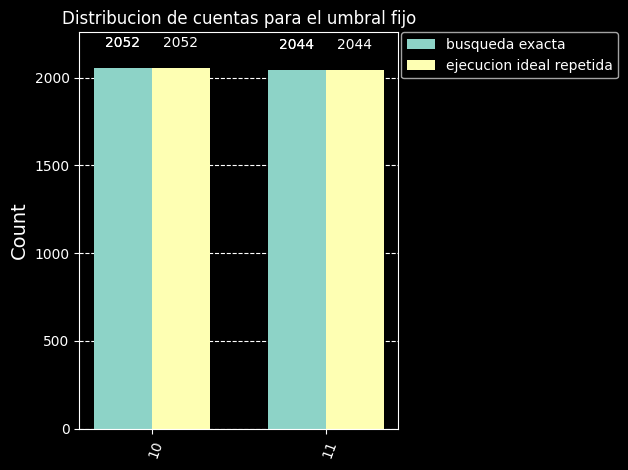

,ronda,valor_actual,iteraciones_grover,profundidad,multi_qubit_ops
0,1,7,1,10,4
1,2,0,0,0,0


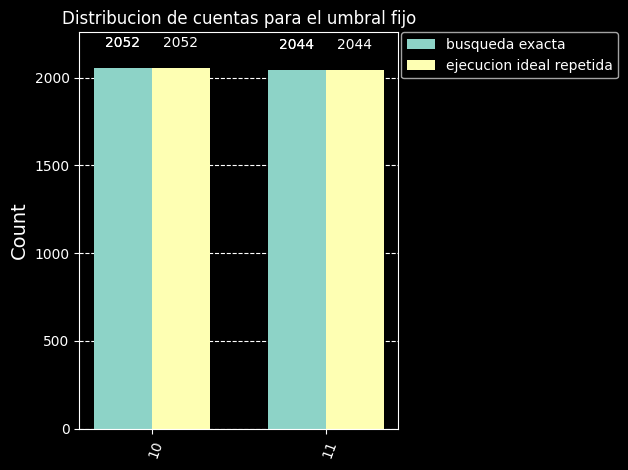

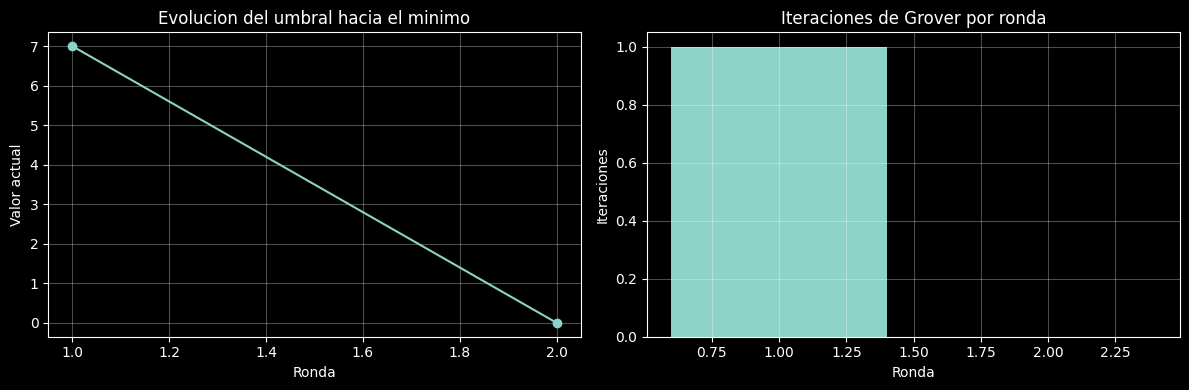

In [18]:
display(
    plot_histogram(
        [threshold_search_exact["counts"], ideal_counts_demo],
        legend=["busqueda exacta", "ejecucion ideal repetida"],
        title="Distribucion de cuentas para el umbral fijo",
    )
)

history_min_df = qummsa_min_result["history"].copy()
display(history_min_df[["ronda", "valor_actual", "iteraciones_grover", "profundidad", "multi_qubit_ops"]])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_min_df["ronda"], history_min_df["valor_actual"], marker="o")
axes[0].set_title("Evolucion del umbral hacia el minimo")
axes[0].set_xlabel("Ronda")
axes[0].set_ylabel("Valor actual")
axes[0].grid(alpha=0.3)

axes[1].bar(history_min_df["ronda"], history_min_df["iteraciones_grover"])
axes[1].set_title("Iteraciones de Grover por ronda")
axes[1].set_xlabel("Ronda")
axes[1].set_ylabel("Iteraciones")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Implementación de una línea base inspirada en Dürr-Høyer

> La comparación que nos interesa no es contra una implementación clásica, sino contra una subrutina cuántica menos afinada. Para eso usamos una línea base que conserva la misma estructura iterativa, pero reemplaza el ajuste de fase de Grover-Long por la versión estándar de Grover con número de iteraciones redondeado. Es una simplificación razonable del contraste conceptual que plantea el artículo.

In [19]:
def run_durr_hoyer_like(
    values: list[int],
    objective: str = "min",
    initial_index: int | None = None,
    shots: int = 2048,
    stop_patience: int = 2,
 ) -> dict:
    return run_qummsa(
        values,
        objective=objective,
        initial_index=initial_index,
        shots=shots,
        exact_phase_matching=False,
        stop_patience=stop_patience,
    )


baseline_min_result = run_durr_hoyer_like(
    DATASET,
    objective="min",
    initial_index=0,
    shots=4096,
    stop_patience=2,
 )

display(baseline_min_result["history"])
print(
    f"Resultado base: indice {baseline_min_result['final_index']} ",
    f"-> valor {baseline_min_result['final_value']}"
 )

,ronda,indice_actual,valor_actual,M,iteraciones_grover,fase_rad,profundidad,multi_qubit_ops,estado_ganador,indice_ganador,valor_ganador,ganador_marcado,ganador_valido,runtime_sec,estrategia,mejora,motivo
0,1,0,7,3,0,3.141593,2,0,00,0.0,7.0,False,True,0.013172,grover_estandar,False,Sin mejora
1,2,0,7,3,0,3.141593,2,0,01,1.0,5.0,True,True,0.006248,grover_estandar,True,Actualizacion
2,3,1,5,2,0,3.141593,2,0,10,2.0,0.0,True,True,0.008921,grover_estandar,True,Actualizacion
3,4,2,0,0,0,0.000000,0,0,NaN,NaN,NaN,False,False,0.000000,sin_candidatos,False,No quedan candidatos mejores


Resultado base: indice 2  -> valor 0


## 14. Comparación experimental entre QUMMSA y la línea base

> A continuación repetimos el experimento sobre varios tamaños de dataset y varios casos aleatorios. No buscamos una prueba estadística definitiva, sino una comparación experimental razonable y reproducible dentro de Qiskit. Las métricas elegidas son tasa de éxito, número de rondas, profundidad acumulada, compuertas multiqubit y tiempo de simulación.

In [20]:
def evaluate_algorithm(
    values: list[int],
    algorithm: str,
    objective: str = "min",
    initial_index: int = 0,
    shots: int = 1024,
    stop_patience: int = 2,
 ) -> dict:
    start_time = time.perf_counter()

    if algorithm == "QUMMSA":
        result = run_qummsa(
            values,
            objective=objective,
            initial_index=initial_index,
            shots=shots,
            exact_phase_matching=True,
            stop_patience=stop_patience,
        )
    elif algorithm == "Durr-Hoyer-like":
        result = run_durr_hoyer_like(
            values,
            objective=objective,
            initial_index=initial_index,
            shots=shots,
            stop_patience=stop_patience,
        )
    else:
        raise ValueError("Algoritmo no reconocido.")

    runtime_sec = time.perf_counter() - start_time
    history = result["history"]
    reference = classical_reference(values)
    expected_index = reference["min_index"] if objective == "min" else reference["max_index"]

    return {
        "algoritmo": algorithm,
        "tamano": len(values),
        "initial_index": initial_index,
        "success": result["final_index"] == expected_index,
        "rondas": int(len(history)),
        "profundidad_total": int(history["profundidad"].fillna(0).sum()),
        "multi_qubit_ops_total": int(history["multi_qubit_ops"].fillna(0).sum()),
        "grover_iters_total": int(history["iteraciones_grover"].fillna(0).sum()),
        "runtime_sec": float(runtime_sec),
    }


def benchmark_algorithms(
    sizes: tuple[int, ...] = (4, 8, 16),
    trials: int = 6,
    objective: str = "min",
    shots: int = 1024,
 ) -> pd.DataFrame:
    rows = []

    for size in sizes:
        local_rng = np.random.default_rng(SEED + size)
        for trial in range(trials):
            values = local_rng.permutation(np.arange(size)).tolist()
            initial_index = int(local_rng.integers(0, size))

            for algorithm in ["QUMMSA", "Durr-Hoyer-like"]:
                row = evaluate_algorithm(
                    values,
                    algorithm=algorithm,
                    objective=objective,
                    initial_index=initial_index,
                    shots=shots,
                )
                row["trial"] = trial
                rows.append(row)

    return pd.DataFrame(rows)


benchmark_min_df = benchmark_algorithms(sizes=(4, 8, 16), trials=6, objective="min", shots=1024)
benchmark_summary_df = (
    benchmark_min_df.groupby(["algoritmo", "tamano"], as_index=False)
    .agg(
        tasa_exito=("success", "mean"),
        rondas_promedio=("rondas", "mean"),
        profundidad_promedio=("profundidad_total", "mean"),
        multiqubit_promedio=("multi_qubit_ops_total", "mean"),
        grover_iters_promedio=("grover_iters_total", "mean"),
        runtime_promedio_sec=("runtime_sec", "mean"),
    )
)

display(benchmark_summary_df.round(4))

,algoritmo,tamano,tasa_exito,rondas_promedio,profundidad_promedio,multiqubit_promedio,grover_iters_promedio,runtime_promedio_sec
0,Durr-Hoyer-like,4,1.0,2.1667,4.3333,1.0000,0.5000,0.0885
1,Durr-Hoyer-like,8,1.0,2.5000,7.6667,2.3333,0.8333,0.1139
2,Durr-Hoyer-like,16,1.0,3.6667,27.6667,11.1667,3.5000,0.1853
3,QUMMSA,4,1.0,2.0000,7.6667,2.8333,1.0000,0.0751
4,QUMMSA,8,1.0,2.8333,20.6667,8.5000,2.1667,0.1287
5,QUMMSA,16,1.0,3.8333,50.0000,22.1667,4.8333,0.2060


## 15. Análisis de complejidad empírica y profundidad de circuitos

> La teoría del artículo habla de complejidad en función de $\sqrt{N}$ y del coste de preparar estados y repetir búsquedas. En esta parte no intentamos reconstruir toda la fórmula analítica del paper dentro del notebook, sino observar si las métricas experimentales siguen la intuición correcta: más tamaño implica más coste, y el ajuste exacto de fase tiende a usar mejor cada ronda de búsqueda.

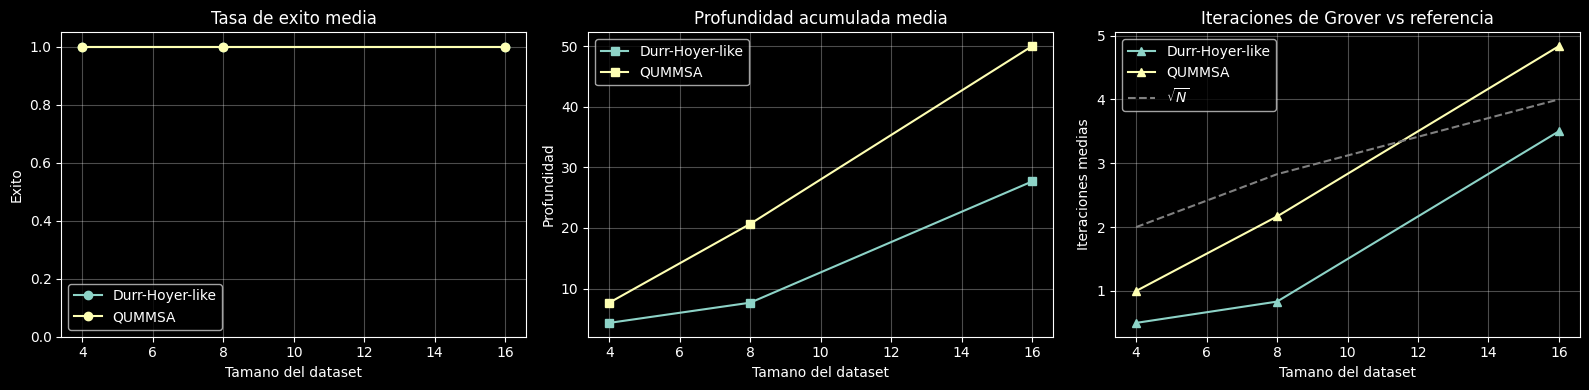

,ronda,iteraciones_grover,profundidad,multi_qubit_ops,runtime_sec
0,1,1,10,4,0.008162
1,2,0,0,0,0.000000


In [21]:
sizes = sorted(benchmark_summary_df["tamano"].unique())
sqrt_reference = np.sqrt(sizes)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for algorithm, subset in benchmark_summary_df.groupby("algoritmo"):
    subset = subset.sort_values("tamano")
    axes[0].plot(subset["tamano"], subset["tasa_exito"], marker="o", label=algorithm)
    axes[1].plot(subset["tamano"], subset["profundidad_promedio"], marker="s", label=algorithm)
    axes[2].plot(subset["tamano"], subset["grover_iters_promedio"], marker="^", label=algorithm)

axes[0].set_title("Tasa de exito media")
axes[0].set_xlabel("Tamano del dataset")
axes[0].set_ylabel("Exito")
axes[0].set_ylim(0, 1.05)
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_title("Profundidad acumulada media")
axes[1].set_xlabel("Tamano del dataset")
axes[1].set_ylabel("Profundidad")
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].plot(sizes, sqrt_reference, linestyle="--", color="gray", label=r"$\sqrt{N}$")
axes[2].set_title("Iteraciones de Grover vs referencia")
axes[2].set_xlabel("Tamano del dataset")
axes[2].set_ylabel("Iteraciones medias")
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

display(
    qummsa_min_result["history"][[
        "ronda",
        "iteraciones_grover",
        "profundidad",
        "multi_qubit_ops",
        "runtime_sec",
    ]]
)

## 16. Simulación con ruido básico y discusión de robustez

> En hardware real, el coste de puertas controladas y la profundidad del circuito importan mucho más que en el simulador ideal. Para capturar esa idea sin salir de Aer, construimos un modelo de ruido simple con errores de una y dos qubits, además de error de lectura. El objetivo no es calibrar una máquina concreta, sino observar la degradación relativa de la distribución de resultados.

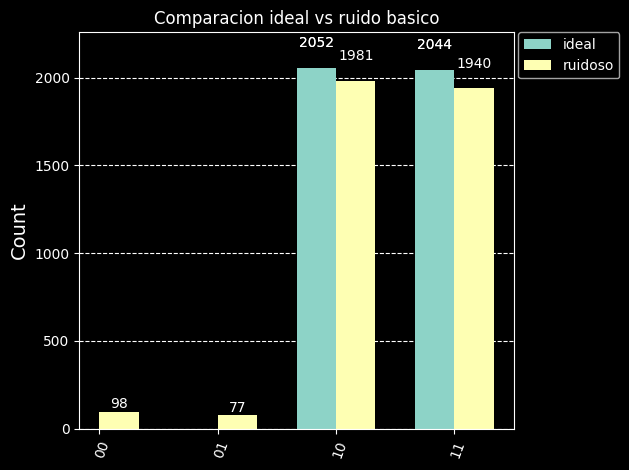

,estado,conteos,probabilidad
0,10,1981,0.483643
1,11,1940,0.473633
2,00,98,0.023926
3,01,77,0.018799


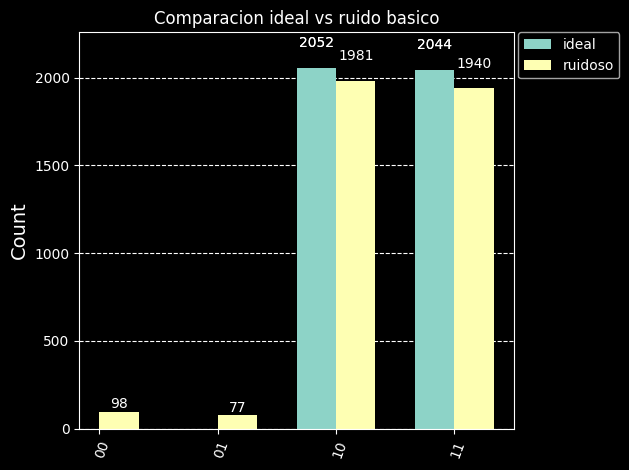

In [22]:
def build_simple_noise_model() -> NoiseModel:
    noise_model = NoiseModel()
    one_qubit_error = depolarizing_error(0.001, 1)
    two_qubit_error = depolarizing_error(0.01, 2)
    readout_error = ReadoutError([[0.98, 0.02], [0.03, 0.97]])

    for gate in ["u", "u1", "u2", "u3", "p", "x", "h", "sx", "rz"]:
        try:
            noise_model.add_all_qubit_quantum_error(one_qubit_error, gate)
        except Exception:
            pass

    for gate in ["cx", "cz", "cp"]:
        try:
            noise_model.add_all_qubit_quantum_error(two_qubit_error, gate)
        except Exception:
            pass

    noise_model.add_all_qubit_readout_error(readout_error)
    return noise_model


simple_noise_model = build_simple_noise_model()
noisy_backend = AerSimulator(noise_model=simple_noise_model, seed_simulator=SEED)
noisy_compiled_demo = transpile(threshold_search_exact["circuit"], noisy_backend)
noisy_counts_demo = noisy_backend.run(noisy_compiled_demo, shots=4096).result().get_counts()

display(
    plot_histogram(
        [ideal_counts_demo, noisy_counts_demo],
        legend=["ideal", "ruidoso"],
        title="Comparacion ideal vs ruido basico",
    )
)
display(execution_summary(noisy_counts_demo, threshold_search_exact["n_qubits"]))

## 17. Funciones reutilizables y pruebas rápidas de validación

> Un notebook técnico gana mucho valor cuando sus piezas principales pueden verificarse rápidamente. En esta última sección ejecutamos comprobaciones cortas sobre el oráculo, la búsqueda sobre umbral y los bucles completos de mínimo y máximo. Si alguna aserción falla, la implementación dejó de ser coherente con el diseño esperado.

In [23]:
def run_quick_checks() -> None:
    single_mark_oracle = phase_oracle_from_indices([2], n_qubits=2, phase=np.pi)
    oracle_diagonal = np.diag(Operator(single_mark_oracle).data)
    assert np.isclose(np.angle(oracle_diagonal[2]) % (2 * np.pi), np.pi)

    gap_padded, gap_valid, _, gap_qubits = pad_dataset(DATASET_WITH_GAP, objective="min")
    gap_marked = better_indices(gap_padded, threshold_value=4, objective="min", valid_mask=gap_valid)
    assert all(gap_valid[index] for index in gap_marked)
    assert gap_qubits == 3

    exact_result = run_threshold_search(
        DATASET,
        threshold_index=threshold_index_demo,
        objective="min",
        exact_phase_matching=True,
        shots=2048,
    )
    assert exact_result["winner_is_marked"]

    assert qummsa_min_result["final_index"] == reference_main["min_index"]
    assert qummsa_max_result["final_index"] == reference_main["max_index"]

    print("Todas las pruebas rapidas pasaron correctamente.")


run_quick_checks()

Todas las pruebas rapidas pasaron correctamente.


## Conclusiones del notebook

> En este cuaderno implementamos una versión práctica de QUMMSA en Qiskit sobre Aer, con oráculos construidos a partir de una tabla clásica de valores, ajuste de fase inspirado en Grover-Long y un bucle iterativo para mínimo y máximo.

> Los resultados reproducen correctamente el mínimo y el máximo del dataset de referencia, permiten inspeccionar circuitos, histogramas y métricas estructurales, e incluyen tanto una comparación con una línea base tipo Dürr-Høyer como una simulación con ruido básico.

> Una observación importante de estas pruebas pequeñas es que la versión exacta no siempre minimiza profundidad: su ventaja principal aparece en el control fino de la amplificación y en la fidelidad conceptual respecto al esquema del artículo, no necesariamente en reducir puertas para instancias diminutas e ideales.